<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_141_so_topic_difference(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본 설정
- 필자 연결망의 구조 변화
- 필자 그룹별 토픽 연결망의 차이

In [3]:
# =================================================================
# 셀 1: 필수 라이브러리 및 한글 폰트 설치
# =================================================================
# ⚠️ 이 셀을 실행한 후에는 반드시 "런타임 다시 시작"을 해야 합니다.

# 1. 라이브러리 설치 (최신 호환 버전)
!pip install -q tomotopy kneed

# 2. 나눔 폰트 설치
!sudo apt-get -qq install fonts-nanum*

# 3. 폰트 캐시 재생성
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("✅ 라이브러리 및 한글 폰트 설치가 완료되었습니다.")
print("🔴 중요: 지금 바로 메뉴에서 [런타임] > [세션 다시 시작]을 실행하세요!")

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ 구글 드라이브 마운트 완료!
1.26.4
✅ 기본 설정 및 라이브러리 임포트 완료!


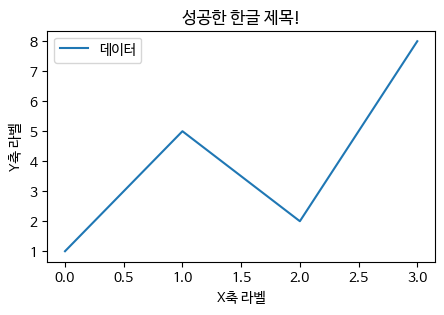

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

# 라이브러리 임포트
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

# ⚠️ 한글 폰트 설정 코드를 여기에 배치합니다.
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 기본 설정 및 라이브러리 임포트 완료!")

# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.데이터 불러오기

In [2]:
# 통합 데이터 불러오기
df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx') ###
df[:3]
# 1기, 2기: doc_id는 3046부터 끝까지
df['period'] = np.where(
    df['doc_id'] < 3046,  # 조건
    'p1',                          # 조건이 참일 때
    'p2'                           # 조건이 거짓일 때
)
df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1
...,...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [3]:
# 저장

# df.to_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls)_period.xlsx')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6802 entries, 0 to 6801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doc_id            6802 non-null   int64 
 1   doc_raw           6802 non-null   object
 2   doc_split_12gram  6802 non-null   object
 3   r_no              6802 non-null   int64 
 4   title             6802 non-null   object
 5   w_new             6802 non-null   object
 6   ho_no             6802 non-null   int64 
 7   grid_1            6802 non-null   object
 8   wn_cls            6802 non-null   int64 
 9   period            6802 non-null   object
dtypes: int64(4), object(6)
memory usage: 531.5+ KB


# 3.1,2기 필자 연결망 비교

## 3.1.'문서별 토픽비중' 불러오기
- doc-distrib.txt

In [5]:
# -*- coding: utf-8 -*-
# 개벽 주요논설 DMR 문서-토픽 분포 → 기간별(1기/2기) 토픽-토픽 코사인유사도 기반 네트워크 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import re
from pathlib import Path

In [6]:
# 문서별 토픽비중 불러오기

doc_dist = pd.read_csv(file_path + 'result/doc-distrib.txt', sep='\t')
doc_dist.drop(columns=['Unnamed: 0'], inplace=True)
doc_dist['doc_id'] = doc_dist.index + 1
doc_dist.set_index('doc_id', inplace=True)
doc_dist

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


In [7]:
name = df[['doc_id', 'w_new']]
name.set_index(['doc_id'],inplace=True)
name

,w_new
doc_id,
1,uk01
2,uk01
3,uk01
4,uk01
5,uk01
...,...
6798,김철산
6799,김철산
6800,김철산


In [8]:
doc_dist_w = pd.concat([doc_dist, name], axis=1)
doc_dist_w

,T0,T1,T2,T3,T4,T5,T6,T7,w_new
doc_id,,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213,uk01
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470,uk01
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738,uk01
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884,uk01
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644,uk01
...,...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290,김철산
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179,김철산
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963,김철산


In [9]:
# 시기별 필자-토픽분포

doc_dist_w_1p = doc_dist_w.query('doc_id < 3046')
doc_dist_w_2p = doc_dist_w.query('doc_id >= 3046')
doc_dist_w_1p

,T0,T1,T2,T3,T4,T5,T6,T7,w_new
doc_id,,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213,uk01
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470,uk01
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738,uk01
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884,uk01
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644,uk01
...,...,...,...,...,...,...,...,...,...
3041,0.870754,0.000178,0.018285,0.000477,0.060587,0.015685,0.032269,0.001766,이동곡
3042,0.853321,0.000636,0.012838,0.001699,0.006610,0.003573,0.010346,0.110977,이동곡
3043,0.977144,0.000346,0.006987,0.000925,0.003597,0.001945,0.005631,0.003426,이동곡


#4.2기 So 토픽 사용 차이

##4.1.분석 대상 문서 선별

### 4.1.1.2기 주요필자 그룹 문서

In [10]:
# 문서별 토픽비중 df에 필자명과 필자분류 열 부착
cls = df[['doc_id', 'wn_cls']]
cls.set_index(['doc_id'],inplace=True)
doc_dist_wncls = pd.concat([doc_dist, name, cls], axis=1)
doc_dist_wncls

,T0,T1,T2,T3,T4,T5,T6,T7,w_new,wn_cls
doc_id,,,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213,uk01,0
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470,uk01,0
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738,uk01,0
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884,uk01,0
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644,uk01,0
...,...,...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290,김철산,2
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179,김철산,2
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963,김철산,2


In [11]:
# 2기의 개벽 주도층, 사회주의자의 문서를 추출

doc_dist_wncls_2p = doc_dist_wncls.query('doc_id >= 3046')
dd2p_wcls12 = doc_dist_wncls_2p.query('wn_cls == 1 or wn_cls == 2') # 개벽 주도층, 사회주의자
dd2p_wcls12

,T0,T1,T2,T3,T4,T5,T6,T7,w_new,wn_cls
doc_id,,,,,,,,,,
3218,0.067180,0.000747,0.011117,0.662519,0.231581,0.007073,0.012825,0.006958,김기전,1
3219,0.024491,0.000272,0.004053,0.380528,0.382289,0.002578,0.004676,0.201113,김기전,1
3220,0.003802,0.000223,0.003326,0.002653,0.623411,0.002116,0.036433,0.328036,김기전,1
3221,0.005641,0.000331,0.004935,0.028115,0.610552,0.027318,0.005693,0.317414,김기전,1
3222,0.006417,0.000377,0.005613,0.334525,0.639507,0.003571,0.006476,0.003513,김기전,1
...,...,...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290,김철산,2
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179,김철산,2
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963,김철산,2


In [12]:
# dd2p_wcls12의 각 문서(행)에서 사회주의 토픽(T3)의 비중이 최대인 문서만 추출

# 비교할 토픽 컬럼 목록을 정의합니다.
topic_columns = ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7']

# 각 행(axis=1)별로 8개 토픽 중 가장 큰 값을 가진 컬럼의 '이름'을 찾습니다.
# (예: 3218행은 'T3', 3220행은 'T4')
max_topic_per_row = dd2p_wcls12[topic_columns].idxmax(axis=1)

# 위에서 찾은 '가장 비중이 큰 토픽'이 'T3'인 행만 선택(필터링)합니다.
t3_dominant_docs = dd2p_wcls12[max_topic_per_row == 'T3']

# 결과 출력 ---
print("--- 각 문서별로 T3 비중이 최대인 문서 ---")
t3_dominant_docs

--- 각 문서별로 T3 비중이 최대인 문서 ---


,T0,T1,T2,T3,T4,T5,T6,T7,w_new,wn_cls
doc_id,,,,,,,,,,
3218,0.067180,0.000747,0.011117,0.662519,0.231581,0.007073,0.012825,0.006958,김기전,1
3229,0.053999,0.000331,0.004935,0.656766,0.030259,0.003140,0.005693,0.244877,김기전,1
3232,0.068993,0.000223,0.101112,0.654561,0.020396,0.002116,0.150517,0.002082,김기전,1
3233,0.007440,0.000437,0.038398,0.674868,0.199355,0.036030,0.039398,0.004073,김기전,1
3277,0.055161,0.000613,0.143306,0.454540,0.011247,0.005808,0.323613,0.005713,김기전,1
...,...,...,...,...,...,...,...,...,...,...
6786,0.002060,0.009209,0.252909,0.478542,0.000427,0.000868,0.002054,0.253931,김철산,2
6787,0.002113,0.009445,0.028626,0.465171,0.000438,0.000890,0.130312,0.363006,김철산,2
6788,0.002658,0.011882,0.003755,0.488441,0.000551,0.323699,0.002651,0.166363,김철산,2


### 4.1.2.해당 문서의 논설 정보

In [13]:
# 1. t3_dominant_docs에 있는 모든 doc_id 리스트를 추출.
dominant_ids = t3_dominant_docs.reset_index()['doc_id']
dominant_ids

,doc_id
0,3218
1,3229
2,3232
3,3233
4,3277
...,...
509,6786
510,6787
511,6788
512,6790


In [14]:
# 문서id 담은 논설 정보 추출

dom_ids = dominant_ids.values.tolist()
dom_df = df[df['doc_id'].isin(dom_ids)][['doc_id', 'r_no', 'title', 'w_new', 'ho_no', 'grid_1']]
dom_df

,doc_id,r_no,title,w_new,ho_no,grid_1
3217,3218,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q
3228,3229,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q
3231,3232,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q
3232,3233,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q
3276,3277,160,"農民運動國産運動이 勃發하기까지, (餓鬼의 威壓에서 解放되려하는 民衆運動의 二三)",김기전,32,11q
...,...,...,...,...,...,...
6785,6786,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q
6786,6787,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q
6787,6788,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q
6789,6790,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q


In [15]:
# 논설별 해당 문서 정보

r_idx = dom_df.groupby(by = ['r_no'])['doc_id'].apply(list)
r_idx

,doc_id
r_no,
157,"[3218, 3229, 3232, 3233]"
160,"[3277, 3280, 3287]"
174,"[3528, 3542]"
180,"[3652, 3653, 3657, 3661, 3662, 3663, 3664, 366..."
185,[3765]
186,"[3774, 3775, 3776, 3777, 3778, 3779, 3780, 378..."
189,"[3797, 3798, 3799, 3800, 3801, 3802, 3803, 380..."
193,"[3862, 3863, 3864, 3868, 3870, 3873, 3878, 387..."
195,[3995]


In [16]:
# 논설에 문서 정보 통합

r_df = df[df['r_no'].isin(r_idx.index)].drop_duplicates(subset=['r_no'])[['r_no', 'title', 'w_new', 'ho_no', 'grid_1', 'wn_cls']]
r_df = r_df.set_index('r_no')
r_df
dom_r_df = pd.concat([r_df, r_idx], axis=1)
dom_r_df

,title,w_new,ho_no,grid_1,wn_cls,doc_id
r_no,,,,,,
157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,"[3218, 3229, 3232, 3233]"
160,"農民運動國産運動이 勃發하기까지, (餓鬼의 威壓에서 解放되려하는 民衆運動의 二三)",김기전,32,11q,1,"[3277, 3280, 3287]"
174,開闢運動과 合致되는 朝鮮의 少年運動,김기전,35,12q,1,"[3528, 3542]"
180,깐듸의 運動과 印度의 無産階級,이성태,37,13q,2,"[3652, 3653, 3657, 3661, 3662, 3663, 3664, 366..."
185,新文學 建設과 한글 整理,양명,38,13q,2,[3765]
186,왼편을 向하야,이성태,38,13q,2,"[3774, 3775, 3776, 3777, 3778, 3779, 3780, 378..."
189,國際無産靑年運動과 朝鮮,주종건,39,13q,2,"[3797, 3798, 3799, 3800, 3801, 3802, 3803, 380..."
193,"빠르쀼스對 로맨ㆍ로란間의 爭論, 클라르테운동의 世界化(끗)1921년 12월 巴里에서.",김기진,40,14q,2,"[3862, 3863, 3864, 3868, 3870, 3873, 3878, 387..."
195,地主는 엇지할고? 특히 副業共進會를 機會로 入京하는 이에게,박달성,40,14q,1,[3995]


In [17]:
# 검수 (2기 T3이 최대 비중인 문서를 포함하는 논설 - 주요 필자 그룹별 분포)

dom_r_df.groupby(by = ['wn_cls'])['title'].count()

,title
wn_cls,
1,17
2,38


## 4.2.DTM(문서-단어 행렬) 생성
- 4.1에서 선별한 문서들의 원본 텍스트(doc_split_12gram)를 가져옵니다.

In [18]:
t3maxidx = t3_dominant_docs.index.tolist() # 2기, 두 그룹 필자 문서 중 T3 비중이 최대인 문서의 index 추출
t3max_df = df[df['doc_id'].isin(t3maxidx)] # df에서 해당 index에 해당하는 문서 추출
t3max_df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
3217,3218,第一의 解放과 第二의 解放 人類歷史上의 二大解放宣言 인류의 역사는 解放의 역사라 한...,해방 해방 역사 인류 인류 역사 해방 역사 역사 해방 역사 해방 바다 역사 세간 내...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3228,3229,우리가 항상 말하는 사회주의적 운동이라 하는 것은 즉 그것이엿다 1918년 월 일 ...,사회_主義 운동 세계 유럽_대전 암흑 해방 선언 발포 러시아 사회_主義 노농 공화 ...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3231,3232,노동共和國의 헌법은 이러한 사정을 잘 짐작하여섯다 例하면 貧乏者의 사상의 자유는 신...,노동 공화 國 헌법 짐작 者 빈핍 사상 자유 신문 출판 필요 기술 물질 수단 지배 ...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3232,3233,그 중에 프랑스의 혁명과 러시아의 혁명이 그 운동의 자최를 가장 크게 함이 되엿다 ...,프랑스_혁명 러시아_혁명 혁명_운동 정치 인권 해방 경제 인권 해방 선언 혁명 금일...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3276,3277,이에서 새로운 국면은 열리기 시작되엿스며 異常한 운동은 일어나기 시작하엿다 먼저 외...,국면 시작 異常 운동 시작 외국 사람 경제 노력 대항 국산 장려 운동 국내 家 유산...,160,"農民運動國産運動이 勃發하기까지, (餓鬼의 威壓에서 解放되려하는 民衆運動의 二三)",김기전,32,11q,1,p2
...,...,...,...,...,...,...,...,...,...,...
6785,6786,그런즉 제일 먼저 제일 만히는 쏘베트聯邦과 싸울 것임니다 이 일종의 고상한 타협끗까...,소비에트 타협 타협 계급 兩 기관 연합 은행 보험 회사 조직 타협 타협 미국 전개 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6786,6787,미국의 經濟上權力은 妥協運動의 根元 그런데 이것이 자본에게 왜 필요하냐고 혹 물을 ...,미국 경제 권력 운동 타협 근원 자본 필요 미국 자본 노력 일반 계획 짐작 대답 미...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6787,6788,이러케 물음에는 과거의 것으로는 도모지 비교하여 볼 수 업는 미국자본의 권력이 대답...,過去 도모 비교 미국 자본 권력 대답 자본_제도 유럽 세계 실험 인류 역사 건설 건...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6789,6790,유럽는 생산력 발전에 가장 준비된 分子들을 물결 뒤로 물결을 니어 大洋건너로 내던젓...,유럽 생산_力 발전 준비 分子 물결 물결 대양 당시 유럽 종교 혁명 정치 혁명 성질...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [19]:
# 문서-단어 행렬
from sklearn.feature_extraction.text import TfidfVectorizer

def get_dtm_1gram(df, col_name, stopw, rank_n): # rank_n : 고빈도 단어 n 순위까지
    '''
    # Tfidf 기반 문서-단어 행렬(dtm) 산출 함수
    '''
    # 단어 종류 모두 벡터화. 1음절 이상
    tv = TfidfVectorizer(ngram_range=(1,1), stop_words=stopw) ## 두 글자 이상
    dtm = tv.fit_transform(df[col_name])

    # tfidf 합계를 사용해 고빈도 단어 추출 (희소 행렬로 작업)
    term_sums = np.array(dtm.sum(axis=0)).flatten()
    highword_indices = term_sums.argsort()[-rank_n:][::-1]  # 상위 rank_n 개 단어 인덱스
    highword_list = [tv.get_feature_names_out()[i] for i in highword_indices]

    # 고빈도 단어(상위 50개)만 포함된 DTM 생성
    feature_dtm = dtm[:, highword_indices]
    feature_df = pd.DataFrame(feature_dtm.toarray(), columns=highword_list, index=df.index)

    return feature_df

In [20]:
# 함수 실행: 상위 50개 단어를 기준으로 DTM 생성
# 제외할 단어
stopw = ['문제', '금일', '관계']
dtm_gb_df = get_dtm_1gram(t3max_df, 'doc_split_12gram', stopw, 1000)
dtm_gb_df

,운동,계급,사회,朝鮮,자본_主義,자유,사람,主義,부르주아,정치,...,배양,열중,成員,독단,충실,파탄,타국,균등,농후,동작
3217,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3228,0.058885,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.076694,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3231,0.113098,0.000000,0.000000,0.0,0.0,0.23624,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3232,0.059366,0.058158,0.000000,0.0,0.0,0.00000,0.156760,0.000000,0.000000,0.154641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3276,0.305389,0.000000,0.000000,0.0,0.0,0.00000,0.134399,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6785,0.000000,0.056377,0.052023,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.151383,0.0,0.0
6786,0.132734,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.084202,0.085674,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
6787,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
6789,0.059475,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.076777,0.077462,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


##4.3.분석용 데이터프레임 결합

In [21]:
# DTM(단어 1000개)과 메타데이터(필자 정보, 그룹 정보)를 결합

combi_dtm = pd.concat([dtm_gb_df, t3max_df[['doc_id', 'w_new', 'wn_cls']]], axis=1).set_index('doc_id')
print(f"--- 분석용 데이터프레임(combi_dtm) 생성 완료 ({len(combi_dtm)}행) ---")
combi_dtm

--- 분석용 데이터프레임(combi_dtm) 생성 완료 (514행) ---


,운동,계급,사회,朝鮮,자본_主義,자유,사람,主義,부르주아,정치,...,成員,독단,충실,파탄,타국,균등,농후,동작,w_new,wn_cls
doc_id,,,,,,,,,,,,,,,,,,,,,
3218,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김기전,1
3229,0.058885,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.076694,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김기전,1
3232,0.113098,0.000000,0.000000,0.0,0.0,0.23624,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김기전,1
3233,0.059366,0.058158,0.000000,0.0,0.0,0.00000,0.156760,0.000000,0.000000,0.154641,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김기전,1
3277,0.305389,0.000000,0.000000,0.0,0.0,0.00000,0.134399,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김기전,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6786,0.000000,0.056377,0.052023,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.151383,0.0,0.0,김철산,2
6787,0.132734,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.084202,0.085674,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김철산,2
6788,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,김철산,2


##4.4.핵심 단어 통계 분석 (LLR 검정)
- 텍스트 분석(희소 데이터)에 더 적합한 LLR(로그우도비) 검정만 실행

In [22]:
from scipy.stats import chi2_contingency

# LLR 검정과 시각화 함수에서 공통으로 사용할 데이터프레임을 준비합니다.
# reset_index()를 통해 인덱스를 0부터 시작하도록 정렬합니다.
df_analysis = combi_dtm.reset_index(drop=True)

# 1. 피처(X)와 메타데이터 분리
meta_cols = ['w_new', 'wn_cls']
feature_cols = [col for col in df_analysis.columns if col not in meta_cols]
X_numeric = df_analysis[feature_cols]

# 2. DTM을 이진(Binary) 데이터로 변환 (단어 존재: 1, 없음: 0)
X_binary = (X_numeric > 0).astype(int)

# 3. LLR 검정을 위한 타겟(y) 준비 (그룹 1, 2를 -> 0, 1로 변환)
y_group_stats = df_analysis['wn_cls'] - 1

print("--- 4. LLR(로그우도비) 검정 실행 ---")
llr_results = []

# 50개 단어 전체에 대해 LLR 검정 수행
for feature in X_binary.columns:
    # 1. 분할표(contingency table) 생성
    contingency_table = pd.crosstab(y_group_stats, X_binary[feature])

    # (간혹 단어가 한 그룹에만 존재해 2x2 표가 안 만들어지는 경우를 대비한 방어 코드)
    if contingency_table.shape != (2, 2):
        continue

    # 2. LLR 검정 수행 (lambda_="log-likelihood")
    g, p, dof, expected = chi2_contingency(contingency_table, lambda_="log-likelihood")

    # 3. 결과 저장
    llr_results.append({
        '단어': feature,
        'LLR 통계량(G)': g,
        'p_value': p
    })

# 4. 결과 정리 (통계량이 높은 순 = 두 그룹 간 차이가 큰 순)
results_llr = pd.DataFrame(llr_results).sort_values(by='LLR 통계량(G)', ascending=False)

print("결과: '개벽주도층(1)'과 '사회주의자(2)'를 구분하는 주요 단어 (LLR 검정)")
print(results_llr.head(10))
print("\n")

--- 4. LLR(로그우도비) 검정 실행 ---
결과: '개벽주도층(1)'과 '사회주의자(2)'를 구분하는 주요 단어 (LLR 검정)
        단어  LLR 통계량(G)   p_value
891     도학   15.990570  0.000064
50   계급_意識   13.586333  0.000228
0       운동   10.592600  0.001135
155     正義    9.481725  0.002075
139     인간    9.337646  0.002245
8     부르주아    8.694161  0.003192
184     唯物    8.568623  0.003420
335     양심    8.568623  0.003420
751     윤리    8.370131  0.003814
2       사회    8.313435  0.003935




## 4.5.분석 결과 확인 및 시각화


--- 1. 상위 10개 단어 개별 빈도표(Crosstab) ---

[도학] 단어의 그룹별 사용 빈도표:
도학      '도학' 없음  '도학' 있음
wn_cls                  
개벽주도층        32        4
사회주의자       478        0

[계급_意識] 단어의 그룹별 사용 빈도표:
계급_意識   '계급_意識' 없음  '계급_意識' 있음
wn_cls                        
개벽주도층           28           8
사회주의자          462          16

[운동] 단어의 그룹별 사용 빈도표:
운동      '운동' 없음  '운동' 있음
wn_cls                  
개벽주도층        16       20
사회주의자       348      130

[正義] 단어의 그룹별 사용 빈도표:
正義      '正義' 없음  '正義' 있음
wn_cls                  
개벽주도층        30        6
사회주의자       466       12

[인간] 단어의 그룹별 사용 빈도표:
인간      '인간' 없음  '인간' 있음
wn_cls                  
개벽주도층        29        7
사회주의자       460       18

[부르주아] 단어의 그룹별 사용 빈도표:
부르주아    '부르주아' 없음  '부르주아' 있음
wn_cls                      
개벽주도층          36          0
사회주의자         400         78

[唯物] 단어의 그룹별 사용 빈도표:
唯物      '唯物' 없음  '唯物' 있음
wn_cls                  
개벽주도층        32        4
사회주의자       474        4

[양심] 단어의 그룹별 사용 빈도표:
양심      '양심' 없음  '양심' 있음
wn_cls         

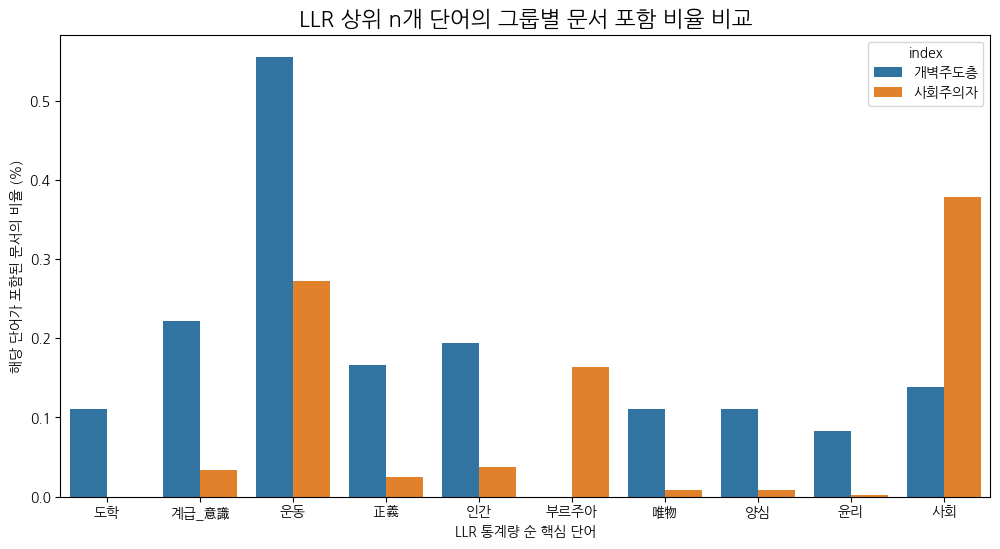

In [23]:
# LLR 검정 결과, 통계적으로 가장 유의미한 상위 10개 단어를 추출합니다.
words_to_check = results_llr.head(10)['단어'].tolist()

# 시각화 함수에서 사용할 그룹 맵 (원본 wn_cls 값 1, 2 기준)
group_map = {1: '개벽주도층', 2: '사회주의자'}

# helper 함수들은 이전에 생성한 df_analysis와 X_binary를 공통으로 사용합니다.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ====================================================================
# 1. 함수 정의
# ====================================================================

def analyze_crosstab(df, X_binary, word_to_analyze, group_map):
    """
    (Helper 1) 특정 단어의 그룹별 '사용 빈도(개수)' 표를 출력합니다.
    """
    # df_analysis의 'wn_cls' (1, 2)와 X_binary의 단어(0, 1)로 교차표 생성
    crosstab_result = pd.crosstab(df['wn_cls'], X_binary[word_to_analyze])

    # 보기 쉽게 이름 변경
    crosstab_result = crosstab_result.rename(index=group_map)
    crosstab_result = crosstab_result.rename(columns={0: f"'{word_to_analyze}' 없음", 1: f"'{word_to_analyze}' 있음"})

    print(f"\n[{word_to_analyze}] 단어의 그룹별 사용 빈도표:")
    print(crosstab_result)


def visualize_proportions(df, X_binary, words_to_check, group_map):
    """
    (Helper 2) 주어진 단어 목록의 그룹별 '사용 비율(%)'을 막대그래프로 시각화합니다.
    """
    # 원본 데이터(df_analysis)에 이진 DTM(X_binary)을 합쳐서 계산 준비
    analysis_df = pd.concat([df[['wn_cls']], X_binary[words_to_check]], axis=1)

    # 그룹별로 각 단어가 포함된 '문서의 비율' 계산
    group_counts = analysis_df['wn_cls'].value_counts()
    proportions = analysis_df.groupby('wn_cls').sum().div(group_counts, axis=0)
    proportions = proportions.rename(index=group_map)

    # 보기 쉽게 데이터 형태 변환 (Melt)
    proportions.index.name = 'index'
    proportions_melted = proportions.reset_index().melt(id_vars='index', var_name='단어', value_name='문서 포함 비율')

    # 막대그래프 시각화
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    plt.figure(figsize=(12, 6))

    sns.barplot(data=proportions_melted, x='단어', y='문서 포함 비율', hue='index')
    plt.title('LLR 상위 n개 단어의 그룹별 문서 포함 비율 비교', fontsize=16)
    plt.ylabel('해당 단어가 포함된 문서의 비율 (%)')
    plt.xlabel('LLR 통계량 순 핵심 단어')
    plt.show()

# ====================================================================
# 2. 함수 실행
# ====================================================================

print("\n--- 1. 상위 10개 단어 개별 빈도표(Crosstab) ---")
# df_analysis와 X_binary는 4.4에서 이미 인덱스가 정렬되었습니다.
for word in words_to_check:
    analyze_crosstab(df_analysis, X_binary, word, group_map)

print("\n--- 2. 상위 10개 단어 그룹별 사용 비율 시각화 ---")
visualize_proportions(df_analysis, X_binary, words_to_check, group_map)


--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---

[발달] 단어의 그룹별 사용 빈도표:
발달      '발달' 없음  '발달' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       407       71

[혁신] 단어의 그룹별 사용 빈도표:
혁신      '혁신' 없음  '혁신' 있음
wn_cls                  
개벽주도층        31        5
사회주의자       468       10

[형제] 단어의 그룹별 사용 빈도표:
형제      '형제' 없음  '형제' 있음
wn_cls                  
개벽주도층        33        3
사회주의자       476        2

[자본_主義] 단어의 그룹별 사용 빈도표:
자본_主義   '자본_主義' 없음  '자본_主義' 있음
wn_cls                        
개벽주도층           35           1
사회주의자          386          92

[선언] 단어의 그룹별 사용 빈도표:
선언      '선언' 없음  '선언' 있음
wn_cls                  
개벽주도층        32        4
사회주의자       471        7

[해방] 단어의 그룹별 사용 빈도표:
해방      '해방' 없음  '해방' 있음
wn_cls                  
개벽주도층        29        7
사회주의자       451       27

[동포] 단어의 그룹별 사용 빈도표:
동포      '동포' 없음  '동포' 있음
wn_cls                  
개벽주도층        34        2
사회주의자       478        0

[폐해] 단어의 그룹별 사용 빈도표:
폐해      '폐해' 없음  '폐해' 있음
wn_cls                  
개벽주도층  

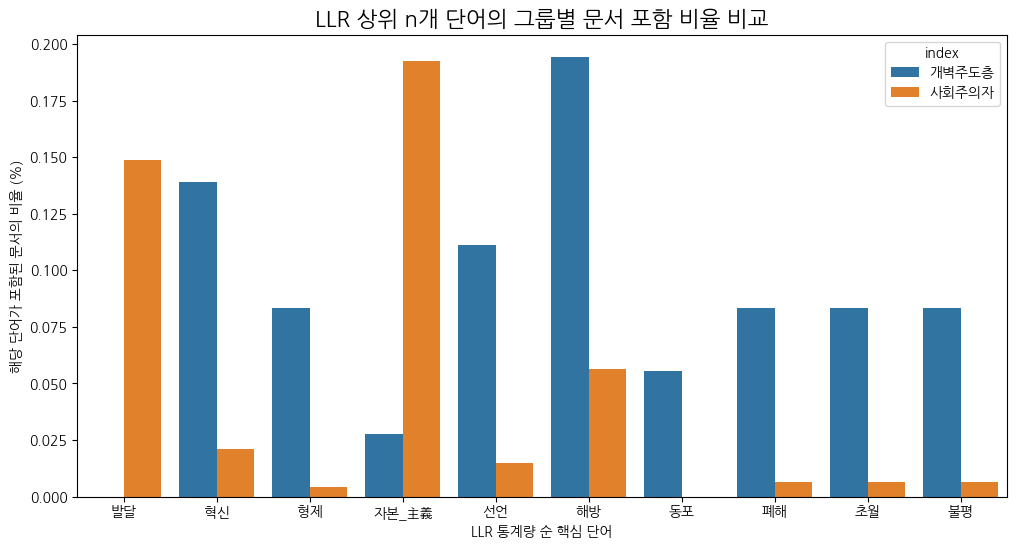

In [25]:
# 1000개 단어의 11~20위 단어

# LLR 검정 결과, 단어를 추출합니다.
words_to_check_11_20 = results_llr['단어'].tolist()[11:21]

print("\n--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---")
# df_analysis와 X_binary는 4.4에서 이미 인덱스가 정렬되었습니다.
for word in words_to_check_11_20:
    analyze_crosstab(df_analysis, X_binary, word, group_map)

print("\n--- 2. 마지막 10개 단어 그룹별 사용 비율 시각화 ---")
visualize_proportions(df_analysis, X_binary, words_to_check_11_20, group_map)


--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---

[무산_계급] 단어의 그룹별 사용 빈도표:
무산_계급   '무산_계급' 없음  '무산_계급' 있음
wn_cls                        
개벽주도층           36           0
사회주의자          422          56

[국내] 단어의 그룹별 사용 빈도표:
국내      '국내' 없음  '국내' 있음
wn_cls                  
개벽주도층        33        3
사회주의자       474        4

[절규] 단어의 그룹별 사용 빈도표:
절규      '절규' 없음  '절규' 있음
wn_cls                  
개벽주도층        33        3
사회주의자       474        4

[대상] 단어의 그룹별 사용 빈도표:
대상      '대상' 없음  '대상' 있음
wn_cls                  
개벽주도층        33        3
사회주의자       473        5

[有機] 단어의 그룹별 사용 빈도표:
有機      '有機' 없음  '有機' 있음
wn_cls                  
개벽주도층        34        2
사회주의자       477        1

[국산] 단어의 그룹별 사용 빈도표:
국산      '국산' 없음  '국산' 있음
wn_cls                  
개벽주도층        34        2
사회주의자       477        1

[시대] 단어의 그룹별 사용 빈도표:
시대      '시대' 없음  '시대' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       433       45

[자본_家] 단어의 그룹별 사용 빈도표:
자본_家    '자본_家' 없음  '자본_家' 있음
wn_cls                    

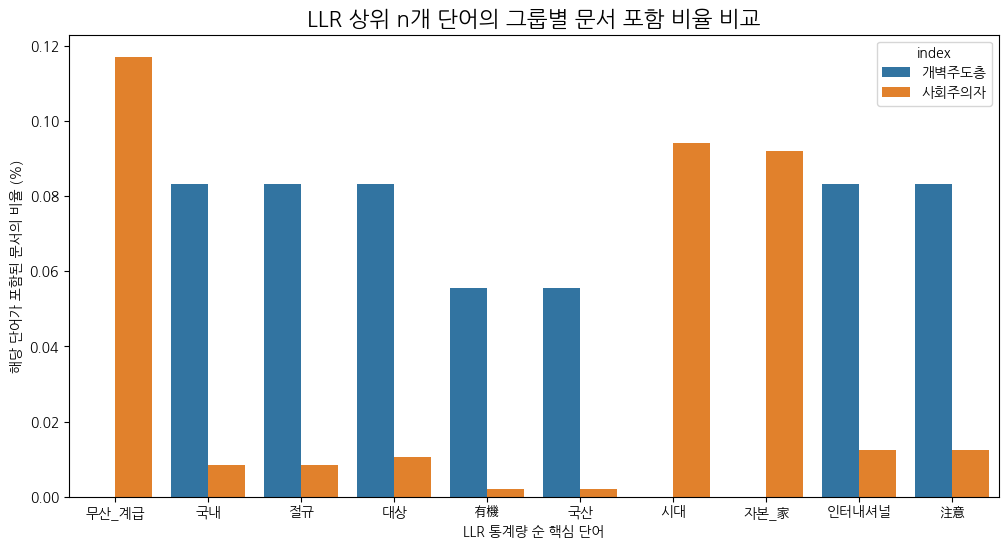

In [26]:
# 1000개 단어의 21~30위 단어

# LLR 검정 결과, 단어를 추출합니다.
words_to_check_21_30 = results_llr['단어'].tolist()[21:31]

print("\n--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---")
# df_analysis와 X_binary는 4.4에서 이미 인덱스가 정렬되었습니다.
for word in words_to_check_21_30:
    analyze_crosstab(df_analysis, X_binary, word, group_map)

print("\n--- 2. 마지막 10개 단어 그룹별 사용 비율 시각화 ---")
visualize_proportions(df_analysis, X_binary, words_to_check_21_30, group_map)


--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---

[고유] 단어의 그룹별 사용 빈도표:
고유      '고유' 없음  '고유' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       473        5

[공황] 단어의 그룹별 사용 빈도표:
공황      '공황' 없음  '공황' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       475        3

[원시] 단어의 그룹별 사용 빈도표:
원시      '원시' 없음  '원시' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       472        6

[삭제] 단어의 그룹별 사용 빈도표:
삭제      '삭제' 없음  '삭제' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       475        3

[기관] 단어의 그룹별 사용 빈도표:
기관      '기관' 없음  '기관' 있음
wn_cls                  
개벽주도층        34        2
사회주의자       452       26

[자랑] 단어의 그룹별 사용 빈도표:
자랑      '자랑' 없음  '자랑' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       473        5

[배경] 단어의 그룹별 사용 빈도표:
배경      '배경' 없음  '배경' 있음
wn_cls                  
개벽주도층        36        0
사회주의자       472        6

[통계] 단어의 그룹별 사용 빈도표:
통계      '통계' 없음  '통계' 있음
wn_cls                  
개벽주도층        36        0
사회주의자    

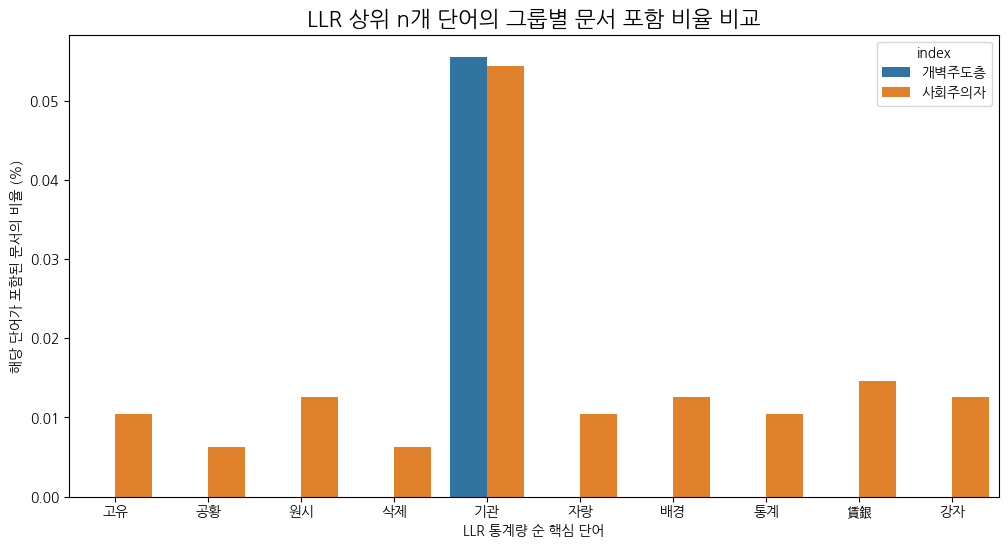

In [24]:
# 1000개 단어의 마지막 10개 단어

# LLR 검정 결과, 단어를 추출합니다.
words_to_check_tail10 = results_llr.tail(10)['단어'].tolist()

print("\n--- 1. 마지막 10개 단어 개별 빈도표(Crosstab) ---")
# df_analysis와 X_binary는 4.4에서 이미 인덱스가 정렬되었습니다.
for word in words_to_check_tail10:
    analyze_crosstab(df_analysis, X_binary, word, group_map)

print("\n--- 2. 마지막 10개 단어 그룹별 사용 비율 시각화 ---")
visualize_proportions(df_analysis, X_binary, words_to_check_tail10, group_map)

# The End of Note